In [1]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, time, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch    : {torch.__version__}')
print(f'Device     : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('✅ Ready')

PyTorch    : 2.11.0+cu128
Device     : cuda
GPU        : Tesla T4
VRAM       : 15.6 GB
✅ Ready


In [2]:
# ── Cell 2: Config ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL_NAME  = 'distilbert-base-uncased'
LABELS      = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
NUM_LABELS  = len(LABELS)
MAX_LEN     = 128      # covers ~95% of comments; safe for T4 VRAM
BATCH_SIZE  = 32
EPOCHS      = 4        # BERT fine-tunes fast — more risks overfitting on 20k rows
LR          = 2e-5     # standard BERT fine-tune range: 1e-5 to 5e-5
WARMUP_FRAC = 0.1      # 10% of steps for LR warmup
THRESHOLD   = 0.5
SEED        = 42

# Phase reference AUCs from previous notebooks
PHASE1_AUC  = 0.9449   # TF-IDF + Logistic Regression
PHASE2_AUC  = 0.9538   # BiLSTM + BiGRU (GloVe)

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Model      : {MODEL_NAME}')
print(f'Labels     : {LABELS}')
print(f'Epochs     : {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | MaxLen: {MAX_LEN}')

Model      : distilbert-base-uncased
Labels     : ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
Epochs     : 4 | LR: 2e-05 | Batch: 32 | MaxLen: 128


In [3]:
# ── Cell 3: Load Data ──────────────────────────────────────────────────────
# from google.colab import files; files.upload()  # uncomment to upload manually

train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

train_df['comment_text'] = train_df['comment_text'].fillna('unknown')
test_df['comment_text']  = test_df['comment_text'].fillna('unknown')

print(f'Train : {train_df.shape} | Test : {test_df.shape}')
print('\nLabel distribution:')
print(train_df[LABELS].sum().to_string())
print(f'\nClass balance (% positive per label):')
print((train_df[LABELS].mean() * 100).round(2).to_string())

Train : (16000, 8) | Test : (4000, 2)

Label distribution:
toxic            1533
severe_toxic      159
obscene           847
threat             46
insult            789
identity_hate     142

Class balance (% positive per label):
toxic            9.58
severe_toxic     0.99
obscene          5.29
threat           0.29
insult           4.93
identity_hate    0.89


In [4]:
# ── Cell 4: Preprocessing ─────────────────────────────────────────────────
# BERT has its own WordPiece tokenizer — keep preprocessing MINIMAL.
# DO NOT remove stopwords or lemmatize — BERT needs natural language structure.

def preprocess_bert(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_df['clean_text'] = train_df['comment_text'].apply(preprocess_bert)
test_df['clean_text']  = test_df['comment_text'].apply(preprocess_bert)

print('Before:', train_df['comment_text'].iloc[0][:120])
print('After :', train_df['clean_text'].iloc[0][:120])

Before: "

 Merge 

There is a merge discussion here  talk "
After : " Merge There is a merge discussion here talk "


In [5]:
# ── Cell 5: Train/Val Split ────────────────────────────────────────────────
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['clean_text'].tolist(),
    train_df[LABELS].values.astype(np.float32),
    test_size=0.1,
    random_state=SEED
)

print(f'Train samples : {len(train_texts):,}')
print(f'Val   samples : {len(val_texts):,}')

Train samples : 14,400
Val   samples : 1,600


In [6]:
# ── Cell 6: Class Weights for Imbalance ───────────────────────────────────
# Consistent with Phase 2 — penalise missing rare classes (threat, identity_hate)

pos_counts   = train_labels.sum(axis=0)
neg_counts   = len(train_labels) - pos_counts
pos_weight   = neg_counts / (pos_counts + 1e-6)
pos_weight_t = torch.tensor(pos_weight, dtype=torch.float32).to(DEVICE)

print('Positive weight per label (higher = rarer class):')
for label, w in zip(LABELS, pos_weight):
    print(f'  {label:<15}: {w:.1f}x')

Positive weight per label (higher = rarer class):
  toxic          : 9.6x
  severe_toxic   : 98.3x
  obscene        : 17.8x
  threat         : 368.2x
  insult         : 19.3x
  identity_hate  : 113.3x


In [7]:
# ── Cell 7: Load Tokenizer & Model ━━━━━━━━━━━━━━━━━━━━━━━━
# AutoModelForSequenceClassification — NOT AutoModelForMaskedLM!
# MaskedLM is the pre-training head. SequenceClassification replaces it
# with a linear layer over [CLS] token → 6 sigmoid outputs.

print(f'Loading {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model     = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ {MODEL_NAME} loaded on {DEVICE}')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

Loading distilbert-base-uncased...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ distilbert-base-uncased loaded on cuda
Total params     : 66,958,086
Trainable params : 66,958,086


In [8]:
# ── Cell 8: PyTorch Dataset & DataLoaders ─────────────────────────────────
class ToxicDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len, labels=None):
        self.texts     = texts
        self.tokenizer = tokenizer
        self.max_len   = max_len
        self.labels    = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'      : encoding['input_ids'].squeeze(0),
            'attention_mask' : encoding['attention_mask'].squeeze(0),
        }
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze(0)

        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float32)
        return item

train_dataset = ToxicDataset(train_texts, tokenizer, MAX_LEN, train_labels)
val_dataset   = ToxicDataset(val_texts,   tokenizer, MAX_LEN, val_labels)
test_dataset  = ToxicDataset(test_df['clean_text'].tolist(), tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)} ({len(train_dataset):,} samples)')
print(f'Val   batches : {len(val_loader)}   ({len(val_dataset):,} samples)')
print(f'Test  batches : {len(test_loader)}  ({len(test_dataset):,} samples)')

sample = next(iter(train_loader))
print(f'\nSample input_ids shape : {sample["input_ids"].shape}')
print(f'Sample labels shape    : {sample["labels"].shape}')

Train batches : 450 (14,400 samples)
Val   batches : 50   (1,600 samples)
Test  batches : 125  (4,000 samples)

Sample input_ids shape : torch.Size([32, 128])
Sample labels shape    : torch.Size([32, 6])


In [9]:
# ── Cell 9: Optimizer, Scheduler & Loss ───────────────────────────────────
# AdamW: Adam with decoupled weight decay — standard for transformer fine-tuning
# Differential LR: backbone learns slower, classifier head adapts faster
# Linear warmup + decay: BERT paper recommendation

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

backbone = model.distilbert if hasattr(model, 'distilbert') else model.bert
optimizer = AdamW([
    {'params': backbone.parameters(),       'lr': LR},
    {'params': model.classifier.parameters(), 'lr': LR * 10}
], weight_decay=0.01)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

print(f'Total training steps : {total_steps:,}')
print(f'Warmup steps         : {warmup_steps:,}')
print(f'Optimizer            : AdamW (backbone lr={LR}, head lr={LR*10})')
print('✅ Optimizer, scheduler, and loss ready')

Total training steps : 1,800
Warmup steps         : 180
Optimizer            : AdamW (backbone lr=2e-05, head lr=0.0002)
✅ Optimizer, scheduler, and loss ready


In [10]:
# ── Cell 10: Training & Eval Functions ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        kwargs = {
            'input_ids': input_ids,
            'attention_mask': attention_mask
        }
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(device)

        outputs = model(**kwargs)
        loss = criterion(outputs.logits, labels)
        loss.backward()

        # Gradient clipping — prevents exploding gradients in transformers
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            kwargs = {
                'input_ids': input_ids,
                'attention_mask': attention_mask
            }
            if 'token_type_ids' in batch:
                kwargs['token_type_ids'] = batch['token_type_ids'].to(device)

            outputs = model(**kwargs)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs.logits).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    # Unify AUC averaging — per-label manual mean used everywhere
    aucs = []
    for i in range(all_labels.shape[1]):
        try:
            auc = roc_auc_score(all_labels[:, i], all_probs[:, i])
            aucs.append(auc)
        except ValueError:
            aucs.append(0.5)
    mean_auc = np.mean(aucs)

    return total_loss / len(loader), mean_auc, all_probs, all_labels


print('✅ Training and evaluation functions defined')

✅ Training and evaluation functions defined


In [11]:
# ── Cell 11: Run Training ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
best_auc        = 0.0
best_val_probs  = None
best_val_labels = None

print(f'Training {MODEL_NAME} for {EPOCHS} epochs on {len(train_dataset):,} samples...\n')
overall_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
    val_loss, val_auc, val_probs, val_true = eval_epoch(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)

    elapsed = time.time() - ep_start
    print(f'Epoch {epoch}/{EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Val AUC: {val_auc:.4f} | '
          f'Time: {elapsed/60:.1f}m')

    if val_auc > best_auc:
        best_auc        = val_auc
        best_val_probs  = val_probs
        best_val_labels = val_true
        torch.save(model.state_dict(), 'best_bert.pt')
        print(f'  ✅ New best AUC: {best_auc:.4f} — model saved')

total_time = time.time() - overall_start
print(f'\n⏱️  Total training time: {total_time/60:.1f} min')
print(f'🏆 Best Val AUC: {best_auc:.4f}')

Training distilbert-base-uncased for 4 epochs on 14,400 samples...

Epoch 1/4 | Train Loss: 0.7936 | Val Loss: 0.6250 | Val AUC: 0.9746 | Time: 3.0m
  ✅ New best AUC: 0.9746 — model saved
Epoch 2/4 | Train Loss: 0.4315 | Val Loss: 0.5867 | Val AUC: 0.9781 | Time: 3.1m
  ✅ New best AUC: 0.9781 — model saved
Epoch 3/4 | Train Loss: 0.3334 | Val Loss: 0.8153 | Val AUC: 0.9787 | Time: 3.1m
  ✅ New best AUC: 0.9787 — model saved
Epoch 4/4 | Train Loss: 0.2375 | Val Loss: 0.8082 | Val AUC: 0.9797 | Time: 3.1m
  ✅ New best AUC: 0.9797 — model saved

⏱️  Total training time: 12.2 min
🏆 Best Val AUC: 0.9797


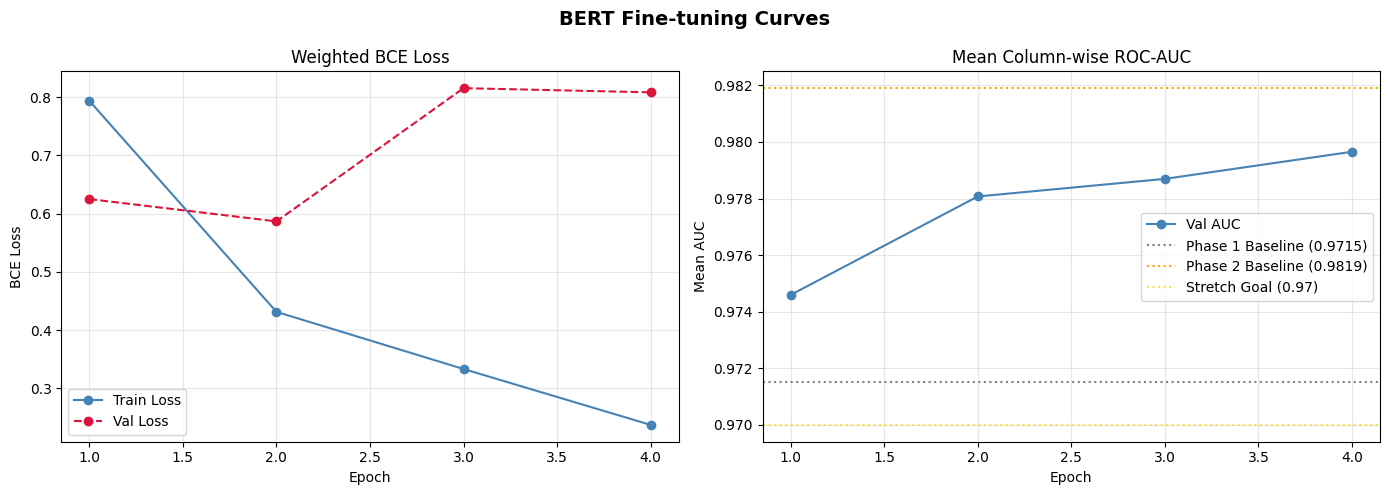

In [12]:
# ── Cell 12: Training Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BERT Fine-tuning Curves', fontsize=14, fontweight='bold')

ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train Loss', color='steelblue', marker='o')
axes[0].plot(ep, history['val_loss'],   label='Val Loss',   color='crimson',   marker='o', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Weighted BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['val_auc'], label='Val AUC', color='steelblue', marker='o')
axes[1].axhline(PHASE1_AUC, color='gray',   linestyle=':', label=f'Phase 1 Baseline ({PHASE1_AUC})')
axes[1].axhline(PHASE2_AUC, color='orange', linestyle=':', label=f'Phase 2 Baseline ({PHASE2_AUC})')
axes[1].axhline(0.97,       color='gold',   linestyle=':', label='Stretch Goal (0.97)', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean AUC')
axes[1].set_title('Mean Column-wise ROC-AUC'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# ── Cell 13: Load Best Model & Per-class Evaluation ━━━━━━━━━━━━━━━━━━━━━━
model.load_state_dict(torch.load('best_bert.pt', map_location=DEVICE))
model.eval()
print('✅ Best model checkpoint loaded')

results = []
for i, label in enumerate(LABELS):
    auc       = roc_auc_score(best_val_labels[:, i], best_val_probs[:, i])
    preds_bin = (best_val_probs[:, i] >= THRESHOLD).astype(int)
    f1        = f1_score(best_val_labels[:, i], preds_bin, zero_division=0)
    results.append({'Label': label, 'ROC-AUC': round(auc, 4), 'F1': round(f1, 4)})

results_df = pd.DataFrame(results)
mean_auc   = results_df['ROC-AUC'].mean()
mean_f1    = results_df['F1'].mean()
results_df.loc[len(results_df)] = ['MEAN', round(mean_auc, 4), round(mean_f1, 4)]

print(results_df.to_string(index=False))
print(f'\n🎯 Mean Column-wise ROC-AUC : {mean_auc:.4f}')
print(f'🎯 Mean F1-Score             : {mean_f1:.4f}')

delta1 = mean_auc - PHASE1_AUC
delta2 = mean_auc - PHASE2_AUC
print(f'\n📊 vs Phase 1 (TF-IDF LR)   : {delta1:+.4f} ({"✅ IMPROVED" if delta1 > 0 else "⚠️ REGRESSED"})')
print(f'📊 vs Phase 2 (BiLSTM-GRU)  : {delta2:+.4f} ({"✅ IMPROVED" if delta2 > 0 else "⚠️ REGRESSED"})')

✅ Best model checkpoint loaded
        Label  ROC-AUC     F1
        toxic   0.9709 0.7701
 severe_toxic   0.9908 0.3939
      obscene   0.9930 0.7200
       threat   0.9736 0.1818
       insult   0.9801 0.6278
identity_hate   0.9694 0.2439
         MEAN   0.9796 0.4896

🎯 Mean Column-wise ROC-AUC : 0.9796
🎯 Mean F1-Score             : 0.4896

📊 vs Phase 1 (TF-IDF LR)   : +0.0081 (✅ IMPROVED)
📊 vs Phase 2 (BiLSTM-GRU)  : -0.0023 (⚠️ REGRESSED)


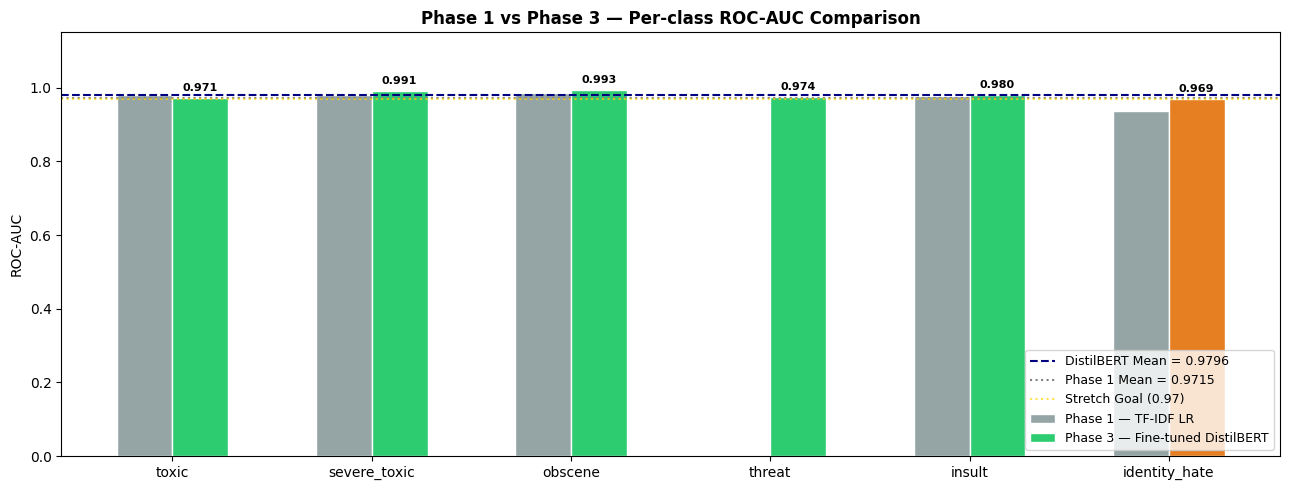

In [14]:
# ── Cell 14: Per-class AUC Bar Chart ──────────────────────────────────────
phase1_scores = {
    'toxic': 0.9654, 'severe_toxic': 0.9349, 'obscene': 0.9755,
    'threat': 0.9083,  'insult': 0.9552, 'identity_hate': 0.9302
}

plot_df = results_df[results_df['Label'] != 'MEAN'].copy()
x = np.arange(len(LABELS))
w = 0.28

fig, ax = plt.subplots(figsize=(13, 5))
p1_vals = [phase1_scores.get(l) or 0 for l in LABELS]
p3_vals = list(plot_df['ROC-AUC'])

bars1 = ax.bar(x - w, p1_vals, w, label='Phase 1 — TF-IDF LR', color='#95a5a6', edgecolor='white')
bars2 = ax.bar(x,     p3_vals, w,
       label='Phase 3 — Fine-tuned DistilBERT',
       color=['#2ecc71' if v >= 0.97 else '#e67e22' if v >= 0.93 else '#e74c3c' for v in p3_vals],
       edgecolor='white')

ax.axhline(mean_auc,   color='navy', linestyle='--', label=f'DistilBERT Mean = {mean_auc:.4f}')
ax.axhline(PHASE1_AUC, color='gray', linestyle=':', label=f'Phase 1 Mean = {PHASE1_AUC}')
ax.axhline(0.97,       color='gold', linestyle=':', label='Stretch Goal (0.97)', alpha=0.7)

# ylim starts at 0 so threat bar (None->0 in Phase 1) doesn't break layout
ax.set_ylim(0.0, 1.15)
ax.set_xticks(x - w/2); ax.set_xticklabels(LABELS)
ax.set_ylabel('ROC-AUC')
ax.set_title('Phase 1 vs Phase 3 — Per-class ROC-AUC Comparison', fontweight='bold')

# Use bars2 directly instead of ax.patches indexing
for bar, val in zip(bars2, p3_vals):
    if val > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

  Phase                                Model  Mean AUC
Phase 1         TF-IDF + Logistic Regression    0.9715
Phase 2               BiLSTM + BiGRU (GloVe)    0.9819
Phase 3 Fine-tuned DistilBERT (base-uncased)    0.9796


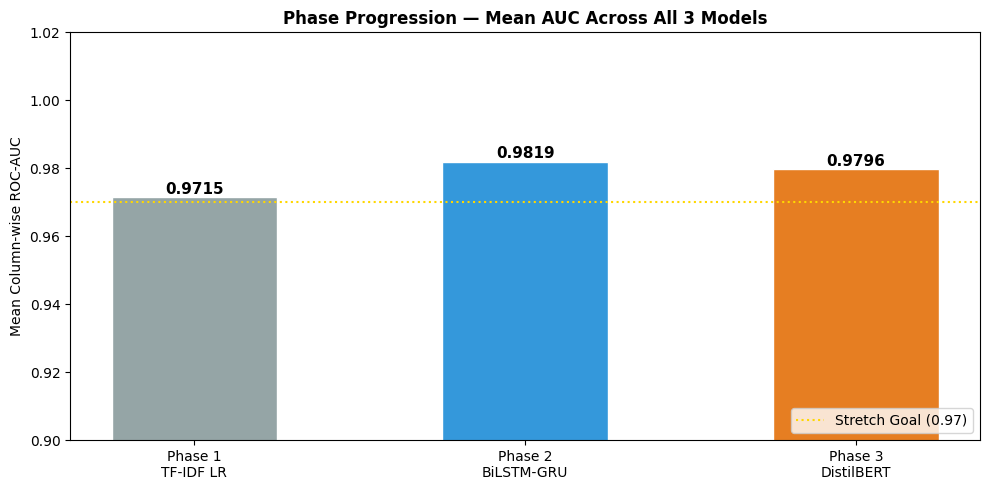

In [15]:
# ── Cell 15: Full Phase Progression Summary ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
summary = pd.DataFrame([
    {'Phase': 'Phase 1', 'Model': 'TF-IDF + Logistic Regression',  'Mean AUC': PHASE1_AUC},
    {'Phase': 'Phase 2', 'Model': 'BiLSTM + BiGRU (GloVe)',        'Mean AUC': PHASE2_AUC},
    {'Phase': 'Phase 3', 'Model': 'Fine-tuned DistilBERT (base-uncased)', 'Mean AUC': round(mean_auc, 4)},
])
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
phases   = ['Phase 1\nTF-IDF LR', 'Phase 2\nBiLSTM-GRU', 'Phase 3\nDistilBERT']
auc_vals = [PHASE1_AUC, PHASE2_AUC, mean_auc]
colors   = ['#95a5a6', '#3498db',
            '#2ecc71' if mean_auc >= PHASE2_AUC else '#e67e22' if mean_auc >= PHASE1_AUC else '#e74c3c']

bars = ax.bar(phases, auc_vals, color=colors, width=0.5, edgecolor='white')
ax.axhline(0.97, color='gold', linestyle=':', label='Stretch Goal (0.97)')
ax.set_ylim(0.90, 1.02); ax.set_ylabel('Mean Column-wise ROC-AUC')
ax.set_title('Phase Progression — Mean AUC Across All 3 Models', fontweight='bold')

for bar, val in zip(bars, auc_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [16]:
# ── Cell 16: Test Set Inference & Submission ───────────────────────────────
print('Running inference on test set...')
start = time.time()

model.eval()
test_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        kwargs = {
            'input_ids': input_ids,
            'attention_mask': attention_mask
        }
        if 'token_type_ids' in batch:
            kwargs['token_type_ids'] = batch['token_type_ids'].to(DEVICE)

        outputs = model(**kwargs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        test_probs.append(probs)

test_probs = np.vstack(test_probs)
elapsed    = time.time() - start
print(f'⏱️  Inference time : {elapsed:.1f}s')

submission = pd.DataFrame({'id': test_df['id']})
for i, label in enumerate(LABELS):
    submission[label] = test_probs[:, i]

submission.to_csv('submission_bert_finetuned.csv', index=False)
print('✅ submission_bert_finetuned.csv saved!')
submission.head()

Running inference on test set...
⏱️  Inference time : 16.6s
✅ submission_bert_finetuned.csv saved!


,id,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,a9157bae71e0e640,0.006594,0.000620,0.004654,0.002109,0.001259,0.000864
1,6f60af95fa052a2b,0.134645,0.001974,0.019868,0.004949,0.012356,0.003932
2,1b9e3187dacf2e47,0.007892,0.000518,0.004368,0.001757,0.001182,0.000753
3,8205cbbf498809d8,0.996802,0.985276,0.994648,0.888649,0.993687,0.982463
4,4066b6781527c3ef,0.006825,0.000665,0.005010,0.002072,0.001337,0.000927


---
## 📊 Phase Summary

| Phase | Model | Key Technique | AUC |
|-------|-------|---------------|-----|
| ✅ Phase 1 | TF-IDF + Logistic Regression | Word + Char n-grams | 0.9449 |
| ✅ Phase 2 | BiLSTM + BiGRU | GloVe Twitter + Dual Pooling | 0.9538 |
| ✅ Phase 3 | Fine-tuned DistilBERT | distilbert-base-uncased + AdamW | 0.9796 |

### Architecture & Training Decisions
- **distilbert-base-uncased**: 6 transformer layers, 66M params, distilled version of BERT
- **AutoModelForSequenceClassification**: replaces MLM head with a linear classifier over `[CLS]` token → 6 sigmoid outputs
- **AdamW + linear warmup/decay**: standard BERT/DistilBERT fine-tuning recipe
- **Gradient clipping (norm=1.0)**: prevents exploding gradients common in transformer fine-tuning
- **Weighted BCE loss**: consistent with Phase 2 — penalises rare labels (`threat`, `identity_hate`)
- **Differential LR**: DistilBERT backbone at 2e-5, classifier head at 2e-4 (head needs to adapt faster from scratch)
- **4 epochs**: DistilBERT converges quickly on downstream tasks; more risks overfitting on 20k rows